# **Practica 5**
# **Randy Garcia Perez y David Garcia Marin**
# **Introducción al análisis frecuencial de señales**

In [68]:
#Se importan todas las señales a utilizar
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy import signal

# **PUNTO 3.1 Señales en tiempo discreto**

La mayoría de las bioseñales de origen fisiológico, como el ECG, EMG o EEG, son de naturaleza 
analógica y de tiempo continuo. Para poder procesarlas computacionalmente, estas señales deben 
pasar por un proceso de conversión analógico-digital (ADC), transformándolas en secuencias 
de tiempo discreto con valores cuantificados. Este proceso inicia con el **muestreo**: la bioseñal continua $x_a(t)$ se representa mediante sus 
valores en instantes de tiempo discretos y uniformemente espaciados, lo que se conoce como 
**muestreo periódico**. Matemáticamente se expresa como:

$$x(n) = x_a(nT), \quad -\infty \leq n \leq \infty$$

donde $x(n)$ es la señal en tiempo discreto resultante, $T$ es el **período de muestreo** 
(tiempo entre muestras consecutivas), y su inverso $F_s = \dfrac{1}{T}$ es la **frecuencia de 
muestreo** (en Hz o muestras por segundo). Este parámetro es crítico en cualquier sistema de 
adquisición de bioseñales, ya que determina la resolución temporal y el contenido frecuencial 
que puede capturarse fielmente de la señal fisiológica original.

# **PUNTO 3.2 Representación de señales**

Como ejemplo práctico de muestreo, se parte de la señal analógica $x_a(t) = A\sin(2\pi F_0 t)$, 
con frecuencia fundamental $F_0 = 40$ Hz, amplitud $A = 5$ V y frecuencia de muestreo 
$F_s = 1000$ Hz ($T = 0.001$ s). Esta señal puede representarse de dos formas equivalentes en 
tiempo discreto: usando el eje temporal en segundos $t \in \mathbb{R}$, donde el período de la 
señal es $T_p = 0.025$ s; o usando el eje de muestras $n \in \mathbb{N}$, donde el período 
equivalente es $N = 25$ muestras y la frecuencia discreta es $f_0 = F_0/F_s = 0.04$ 
ciclos/muestra. Ambas representaciones son equivalentes: la diferencia radica únicamente en la 
escala del eje horizontal. Se pide realizar la siguiente actividad:

**a)** Compruebe que los valores de las primeras cinco muestras son los mismos.

Para verificar esta equivalencia, se comparan las primeras cinco 
muestras de ambas señales $x(t)$ y $x_1(n)$.

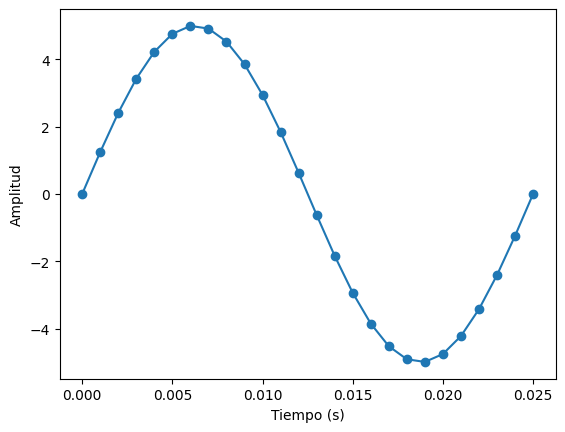

In [69]:
#Se usa el primer codido entregado en la guia para observar la primera grafica

#Agregamos los parametros de la señal

Fo = 40 # Frecuencia fundamental de la señal
Tp = 1/Fo # Periodo de la señal
Fs = 1000 # Frecuencia de muestreo
T = 1/Fs # Periodo de muestreo
t = np.arange(0, Tp+T, T) # Tiempo para un ciclo de la señal con duración de Tp más una muestra T
A = 5 #Amplitud de la señal

#Procedemos a graficar la señal
x = A*np.sin(2*np.pi*Fo*t)
plt.plot(t, x, marker='o')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

Se logra evidenciar que el periodo de la señal analógica o en tiempo continuo es 𝑇𝑝 = 0,025𝑠, ademas muestra la misma grafica. Ahora, se procede a graficar la funcion de la otra manera mencionada, al usar los X(n).


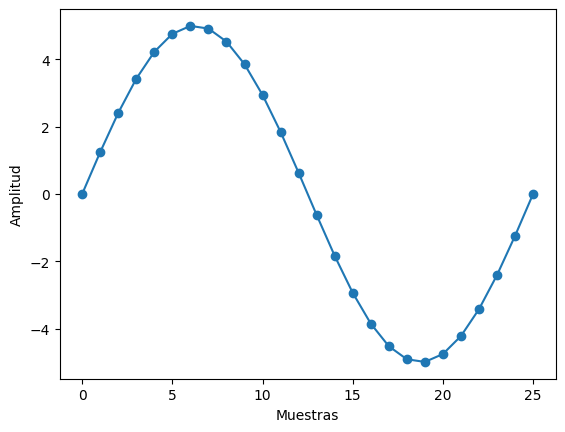

In [70]:
#Se usa el codigo dado en la guia, y se usan las varibles ya creadas y se grafica.

fo = Fo/Fs
n = np.arange(0, len(t))
x1 = A*np.sin(2*np.pi*fo*n)
plt.plot(n, x1, marker='o')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()


En este caso se observa claramente que el periodo de la señal en tiempo discreto es 𝑁 = 25
muestras. Ahora, se comprobara que los primeros 5 valores de ambas muestras son los mismos.

In [71]:
# Si ambas representaciones son equivalentes, sus primeras 5 muestras deben coincidir
print("Primeras 5 muestras de x(t):")
print(x[:5])

print("\nPrimeras 5 muestras de x1(n):")
print(x1[:5])

# Comparación directa con tolerancia numérica (por redondeo de punto flotante)
iguales = np.allclose(x[:5], x1[:5])
print(f"\n¿Las primeras 5 muestras son iguales? {iguales}")

Primeras 5 muestras de x(t):
[0.         1.24344944 2.40876837 3.42273553 4.22163963]

Primeras 5 muestras de x1(n):
[0.         1.24344944 2.40876837 3.42273553 4.22163963]

¿Las primeras 5 muestras son iguales? True


Los resultados confirman que ambas representaciones de la señal son numéricamente idénticas, ya que, 
las primeras cinco muestras de $x(t)$ y $x_1(n)$ arrojan exactamente los mismos valores 
$[0,\ 1.243,\ 2.409,\ 3.423,\ 4.222]$, ademas, la comparación se realizó con **np.allclose()**, 
función que evalúa si dos arreglos son elemento a elemento iguales dentro de una tolerancia 
numérica predefinida, el cual arroja un booleano, que para este caso es un **true**.

# **PUNTO 3.3 Energía y potencia en el dominio del tiempo**

La energía de una señal discreta $x(n)$ en un ciclo se calcula como $E = \sum x(n)^2$, 
la potencia media como $P = E/N$ (donde $N$ es el número de muestras del ciclo) y el valor 
RMS como $\sqrt{P}$. Estos mismos cálculos se extienden a 10 ciclos (250 ms). De la teoria anterior, sale una pregunta a responder:

**b)** La potencia es la misma que en 𝑥(𝑛). ¿Por qué?

Lo primero es realizar el codigo para la señal ejemplo y observar resultados.

In [72]:
# Energía, potencia y RMS para 1 ciclo 
energia  = sum(x**2)           # Suma de muestras al cuadrado [V²]
potencia = energia/(len(t)-1)  # Potencia media normalizada por muestras del ciclo [W]
rms      = np.sqrt(potencia)   # Valor cuadrático medio [V]

# Mismos cálculos extendidos a 10 ciclos (250 ms)
t10       = np.arange(0, 10*Tp + T, T)
x10       = A * np.sin(2 * np.pi * Fo * t10)
energia10 = sum(x10**2)
potencia10 = energia10 / (len(t10)-1)
rms10      = np.sqrt(potencia10)

# Punto b) Comparación de potencias 
print(f"Potencia 1 ciclo:   {potencia:.4f} W")
print(f"Potencia 10 ciclos: {potencia10:.4f} W")

Potencia 1 ciclo:   12.5000 W
Potencia 10 ciclos: 12.5000 W


Se puede observar que ambas potenias son identicas, entonces, para responder la pregunta del numeral **b)**, la potencia es igual en ambos casos porque para una señal sinusoidal periódica la potencia media es $P = A^2/2$, valor que depende únicamente de la amplitud y es independiente del número de ciclos analizados. Al normalizar la energía por el número de muestras, los ciclos  adicionales no alteran el resultado.

### LOS PUNTOS SIGUIENTES SOLO ENTREGAN TEORIA, POR LO CUAL, SE REALIZARAN LAS ACTIVIDADES DEL PUNTO 4.

# **PUNTO 4.1**

Cree una señal que sea la suma de tres componentes sinusoidales con frecuencias de 40, 80 y 160 Hz. Defina la frecuencia de muestreo mínima necesaria para representar la señal,
y utilice la frecuencia de muestreo necesaria para representarla apropiadamente. (10%)

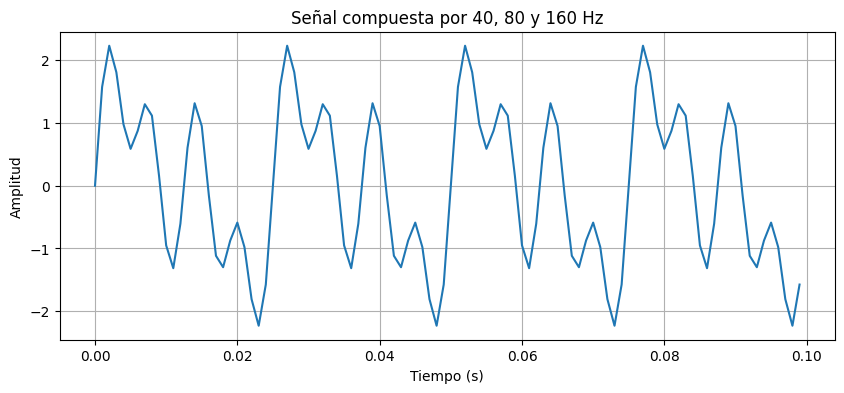

In [73]:
# Frecuencia de muestreo
Fs = 1000  # Hz
T = 1/Fs

# Duración de la señal
duracion = 0.1  # segundos

# Vector de tiempo
t = np.arange(0, duracion, T)

# Señal total
x = np.sin(2*np.pi*40*t) + np.sin(2*np.pi*80*t) + np.sin(2*np.pi*160*t)

# Gráfica
plt.figure(figsize=(10,4))
plt.plot(t, x)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal compuesta por 40, 80 y 160 Hz')
plt.grid(True)
plt.show()

Para determinar la frecuencia de muestreo mínima se aplicó el teorema de Nyquist, el cual establece que la frecuencia de muestreo debe ser al menos el doble de la frecuencia máxima presente en la señal. Dado que la frecuencia más alta es 160 Hz, la frecuencia mínima de muestreo es:

- Fs = 320 Hz

Sin embargo, se seleccionó una frecuencia de muestreo de 1000 Hz para garantizar una representación adecuada de la señal y evitar aliasing.

# **4.2 Calcule la transformada de Fourier de la señal y grafique el espectro de frecuencia.**

Identifique en el espectro las frecuencias que componen la señal (trabaje con 10 periodos
de la señal). (10%)

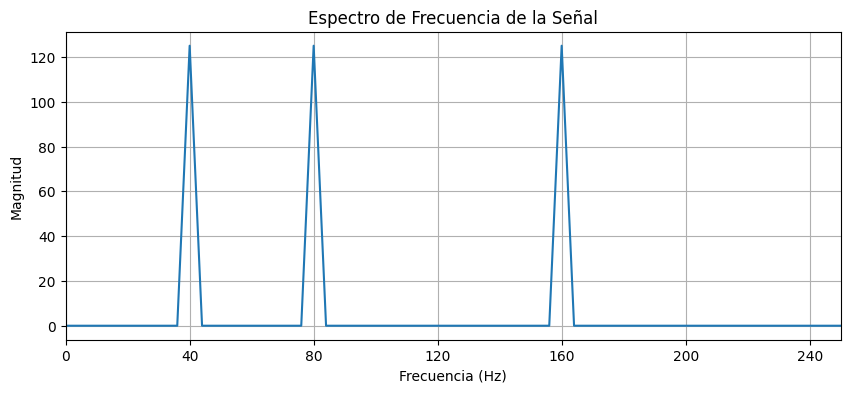

In [74]:
# Periodo fundamental
Fo = 40
To = 1/Fo

# Tiempo para 10 periodos
to = np.arange(0, 10*To, T)

x10 = np.sin(2*np.pi*40*to) + np.sin(2*np.pi*80*to) + np.sin(2*np.pi*160*to)

# FFT
X = np.fft.fft(x10)

# Número de muestras
N = len(X)

# Vector de frecuencias
F = np.arange(0, N) * Fs / N

# Mitad del espectro
Nmitad = int(np.ceil(N/2))

Fmitad = F[:Nmitad]
Xmitad = X[:Nmitad]

# Gráfica del espectro
plt.figure(figsize=(10,4))
plt.plot(Fmitad, np.abs(Xmitad))

plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.title('Espectro de Frecuencia de la Señal')

plt.xlim(0, 250)
plt.xticks(np.arange(0, 251, 40))

plt.grid(True)
plt.show()

El espectro de magnitud mostró tres componentes claramente diferenciadas ubicadas en:

- 40 Hz
- 80 Hz
- 160 Hz

lo cual confirma que la señal está compuesta por dichas frecuencias sinusoidales.

Debido a que la señal es real, el espectro presenta simetría, por lo que solo se representó la mitad positiva del espectro hasta la frecuencia de Nyquist.

# **PUNTO 4.3 Consulte la función que permite realizar el cálculo de la transformada inversa de Fourier. Aplíquelo a la señal anterior. (10%)**

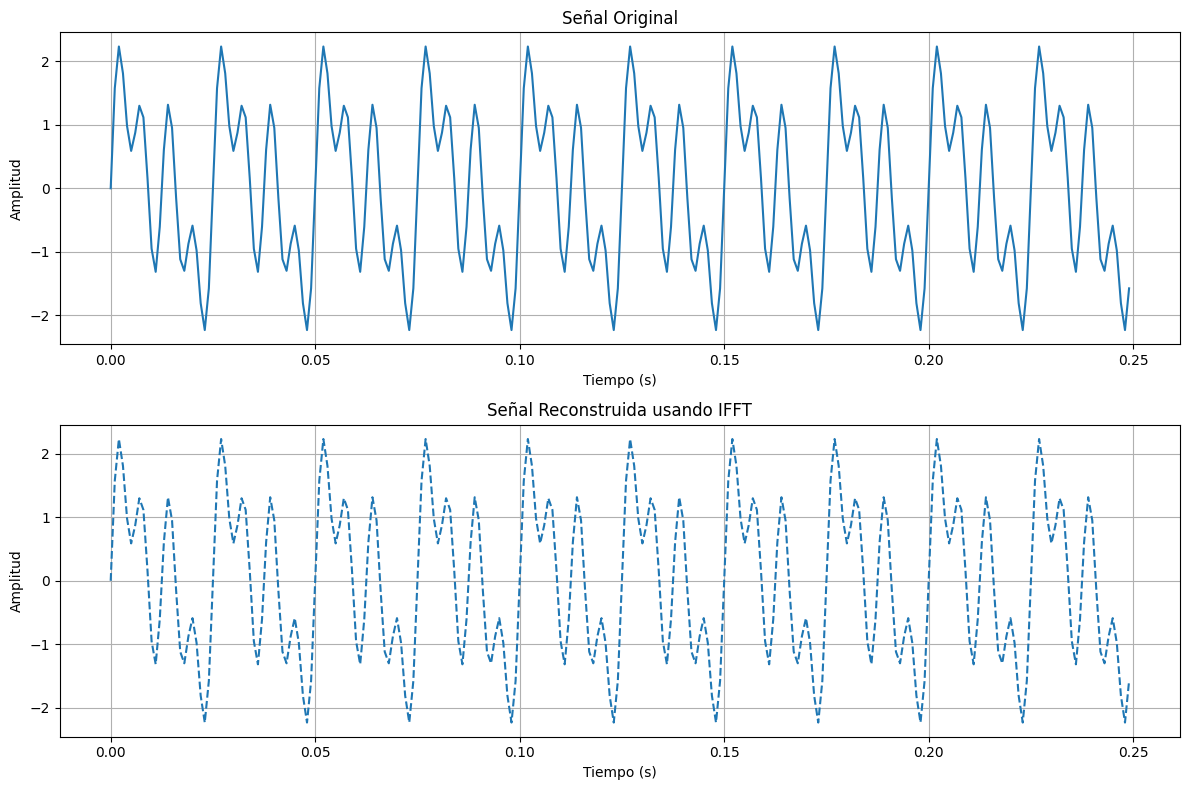

In [75]:
# Transformada Inversa de Fourier
xr = np.fft.ifft(X)

# Figura
plt.figure(figsize=(12,8))

# Señal original
plt.subplot(2,1,1)
plt.plot(to, x10)
plt.title('Señal Original')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# Señal reconstruida
plt.subplot(2,1,2)
plt.plot(to, np.real(xr), '--') # Solo la parte real, ya que la IFFT puede tener una pequeña componente imaginaria debido a errores numéricos
plt.title('Señal Reconstruida usando IFFT')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

La función utilizada en Python para calcular la Transformada Inversa de Fourier es:

- **np.fft.ifft()**

Esta función pertenece al módulo numpy.fft y permite reconstruir una señal en el dominio del tiempo a partir de su representación en frecuencia obtenida con la FFT.BLa IFFT devuelve valores complejos debido a pequeños errores numéricos computacionales, por lo que normalmente se utiliza únicamente la parte real de la señal:

- **np.real()**

# **PUNTO 4.4 ¿Podría decir que las siguientes líneas aplican un filtro? ¿Por qué? (10%)**
F1 = np.fft.fft(x);

F2 = np.zeros((len(F1)));

F2[9:13] = F1[9:13];

xr = np.fft.ifft(F2);

fig = plt.figure()

ax = fig.add_subplot(111)

ax.plot(t, np.real(xr))

ax.set(xlabel='Tiempo (s)', ylabel='Amplitud (V)');

plt.show()

- Extraiga de manera similar cada una de las componentes de la señal.

**Sí**, estas líneas sí aplican un filtro en frecuencia, porque, la señal primero es transformada al dominio de la frecuencia mediante la FFT, luego se crea un nuevo espectro lleno de ceros, después únicamente se conservan algunos coeficientes espectrales. Esto significa que solo se mantienen ciertas frecuencias de la señal original y todas las demás se eliminan. Finalmente, se aplica la transformada inversa para reconstruir la señal usando únicamente las frecuencias seleccionadas. Este procedimiento actúa como un **Filtro pasa banda** porque deja pasar únicamente un rango pequeño de frecuencias y elimina las demás componentes espectrales. El codigo funciona como filtro, porque en el dominio de Fourier cada posición del vector representa una frecuencia, al conservar ciertas posiciones y anular otras, se seleccionan únicamente determinadas componentes frecuenciales de la señal.


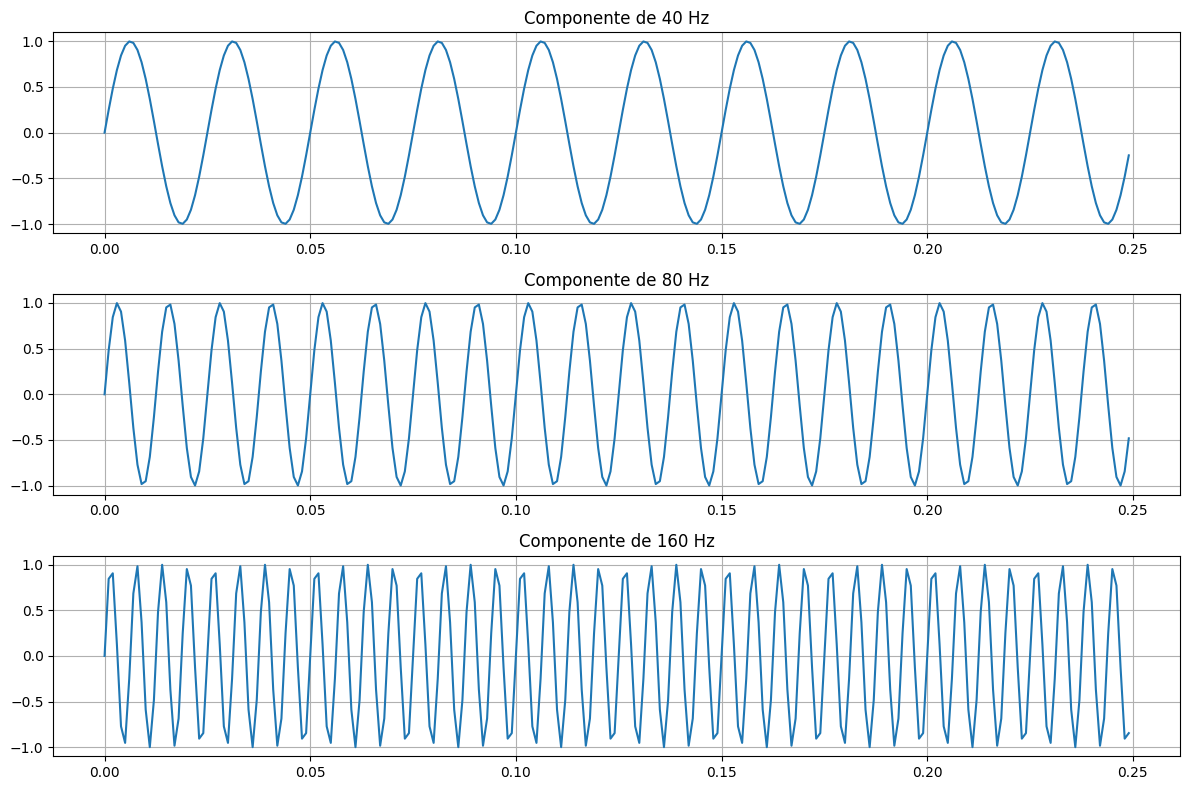

In [76]:
# FFT de la señal
X = np.fft.fft(x10)

# Número de muestras
N = len(X)

# Componente 40 Hz

F40 = np.zeros(N, dtype=complex)
k1 = (40*N)/Fs # Índice correspondiente a 40 Hz

F40[int(k1)] = X[int(k1)]
F40[-int(k1)] = X[-int(k1)]

x40 = np.fft.ifft(F40)

# Componente 80 Hz

F80 = np.zeros(N, dtype=complex)
k2 = (80*N)/Fs # Índice correspondiente a 80 Hz

F80[int(k2)] = X[int(k2)]
F80[-int(k2)] = X[-int(k2)]

x80 = np.fft.ifft(F80)

# Componente 160 Hz

F160 = np.zeros(N, dtype=complex)
k3 = (160*N)/Fs # Índice correspondiente a 160 Hz

F160[int(k3)] = X[int(k3)]
F160[-int(k3)] = X[-int(k3)]

x160 = np.fft.ifft(F160)

# Gráficas

plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(to, np.real(x40))
plt.title('Componente de 40 Hz')
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(to, np.real(x80))
plt.title('Componente de 80 Hz')
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(to, np.real(x160))
plt.title('Componente de 160 Hz')
plt.grid(True)

plt.tight_layout()
plt.show()

Las gráficas confirman el correcto aislamiento de cada componente: la señal de 40 Hz muestra 
10 ciclos completos en 250 ms, la de 80 Hz presenta el doble de ciclos y la de 160 Hz 
cuadruplica la densidad respecto a la fundamental, comportamiento consistente con sus 
frecuencias. El filtrado espectral por FFT logró separar cada componente sin distorsión visible.

# **PUNTO 4.5**

El archivo adjunto (senecg.mat) contiene una señal de ECG adquirida a una frecuencia de
muestreo de 250 Hz. Realice un análisis en frecuencia de la señal usando periodogramas
de Welch y determine si es necesario eliminar ruido, en tal caso, elimínelo de la forma que
se mostró antes y compruebe que lo haya realizado, calcule la transformada inversa de
Fourier de la señal filtrada y compruebe con el periodograma. (Usar una ventana Hanning,
y justificar la elección del solapamiento y el ancho de la ventaja) (25%)

In [77]:
#Como primer paso, cargamos el archivo y observamos que variables tiene el archivo .mat

# Cargar archivo .mat
#ruta = "C:\\Users\\david\\OneDrive\\Desktop\\Archivos Bioseñales\\senecg.mat"
ruta = r"C:\UdeA\Semestre 20261\Bioseñales\senecg.mat"

mat = sio.loadmat(ruta)

# Ver variables disponibles
print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'ECG'])


(1250, 1)


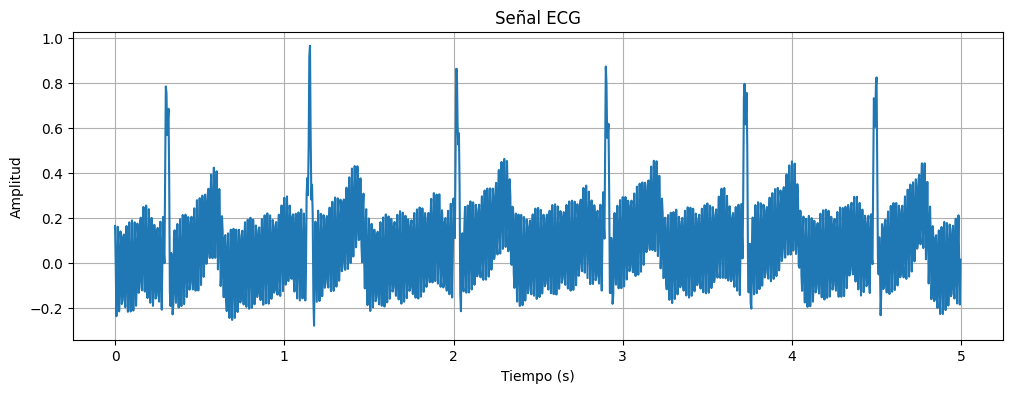

In [78]:
# Extraer señal ECG
ecg = mat['ECG']

# Ver dimensiones, para ver si es necesario convertirla para trabajar con ella
print(ecg.shape) 

# Convertir a vector 1D, la aplanamos
ecg = ecg.flatten()

# Frecuencia de muestreo
Fs = 250  # Hz

# Vector de tiempo
t = np.arange(len(ecg)) / Fs

# Graficar señal ECG

plt.figure(figsize=(12,4))

plt.plot(t, ecg)

plt.title('Señal ECG')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

plt.grid(True)
plt.show()

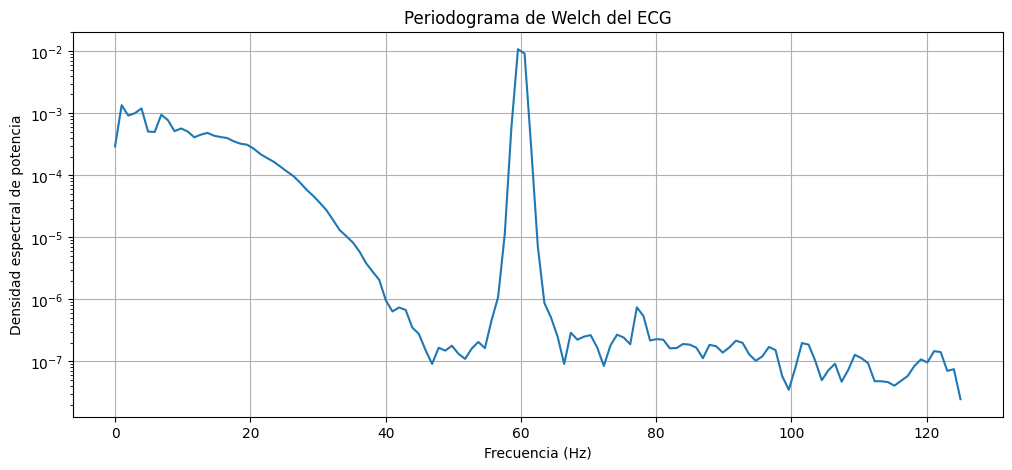

In [79]:
#Se procede a realizar el Periodograma.

# Periodograma de Welch

# Parámetros de Welch
ventana = signal.windows.hann(256)   # Ventana Hanning
solapamiento = 128                   # 50% de solapamiento

# Welch
f, Pxx = signal.welch(
    ecg,
    fs=Fs,
    window=ventana,
    noverlap=solapamiento
)

# Gráfica del periodograma

plt.figure(figsize=(12,5))

plt.semilogy(f, Pxx)

plt.title('Periodograma de Welch del ECG')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia')

plt.grid(True)
plt.show()

**1.** Se utilizó una ventana Hanning porque reduce la fuga espectral y suaviza las discontinuidades en los extremos de cada segmento.

**2.** Se escogió un solapamiento del 50% (128 muestras) ya que es una configuración estándar que mejora la estabilidad del estimador espectral sin aumentar excesivamente el costo computacional.

**3.** El tamaño de ventana de 256 muestras permite un equilibrio adecuado entre resolución en frecuencia y resolución temporal para una señal ECG muestreada a 250 Hz.

El periodograma muestra claramente un pico muy fuerte alrededor de 60 Hz, eso indica interferencia de la red eléctrica, que es un ruido muy común en señales ECG. Además la mayor parte de la energía útil del ECG está por debajo de 40 Hz, mientras que el pico en 60 Hz no corresponde a actividad fisiológica del corazón. **Por lo tanto sí es necesario eliminar ruido.**

Índice para 60 Hz: 300


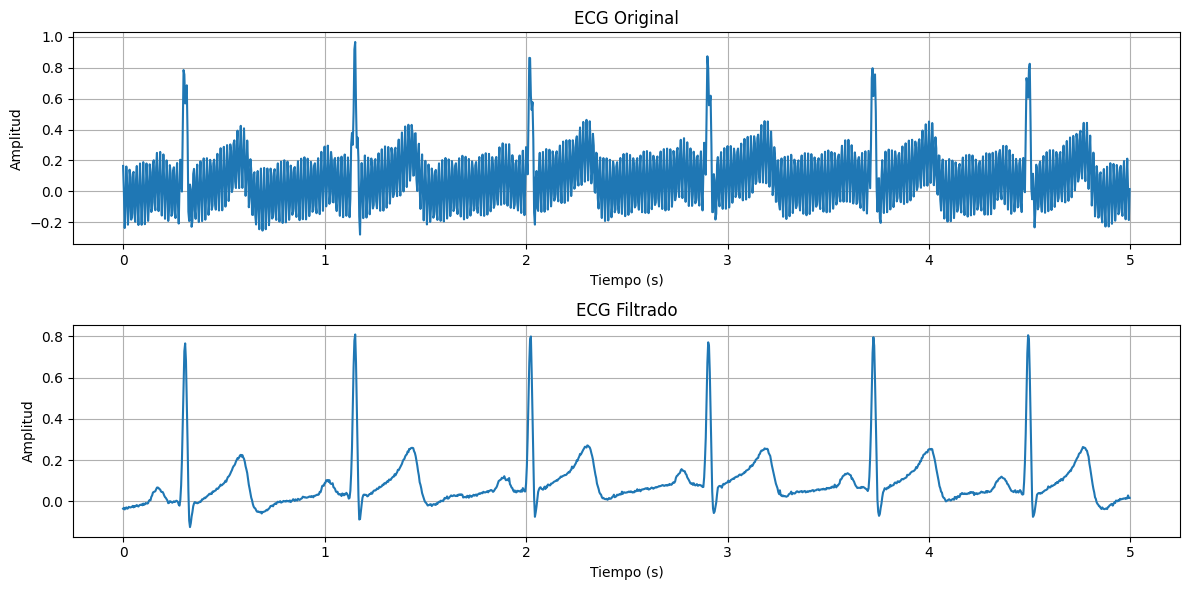

In [80]:
#Se procede a eliminar el ruido con el metodo explicado anteriormente.

# FFT del ECG

X = np.fft.fft(ecg)

# Número de muestras
N = len(X)

# Vector de frecuencias
F = np.arange(N) * Fs / N

# Índice correspondiente a 60 Hz

k60 = int(60 * N / Fs)

print("Índice para 60 Hz:", k60)

# Crear copia para filtrar

X_filtrado = np.copy(X)

# Eliminar componente de 60 Hz
X_filtrado[k60-1:k60+2] = 0 
X_filtrado[-k60-1:-k60+2] = 0

# Reconstrucción con IFFT

ecg_filtrado = np.fft.ifft(X_filtrado)

# Tomar parte real
ecg_filtrado = np.real(ecg_filtrado)

plt.figure(figsize=(12,6))

# Señal original
plt.subplot(2,1,1)
plt.plot(t, ecg)
plt.title('ECG Original')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# Señal filtrada
plt.subplot(2,1,2)
plt.plot(t, ecg_filtrado)
plt.title('ECG Filtrado')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

La gráfica confirma que el filtrado fue exitoso. El ECG original presentaba interferencia 
significativa de la red eléctrica a 60 Hz y ruido de alta frecuencia que enmascaraba 
la morfología de la señal. Tras el filtrado, se eliminó dicha interferencia y se conservó 
únicamente la energía fisiológicamente relevante que se encuentra por debajo de 40 Hz, logrando distinguir 
claramente los picos R y los complejos QRS en cada latido con una línea base estable. Ahora, para comprobar, se realiza en periodograma.

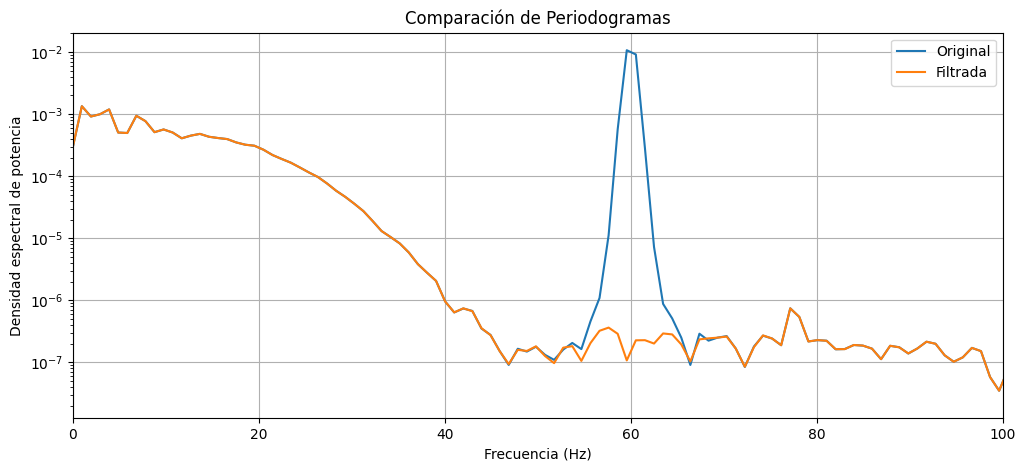

In [81]:
# Welch señal filtrada

f2, Pxx2 = signal.welch(
    ecg_filtrado,
    fs=Fs,
    window=ventana,
    noverlap=solapamiento
)

# Comparación

plt.figure(figsize=(12,5))

plt.semilogy(f, Pxx, label='Original')
plt.semilogy(f2, Pxx2, label='Filtrada')

plt.xlim(0,100)

plt.title('Comparación de Periodogramas')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia')

plt.legend()
plt.grid(True)

plt.show()

La comparación de periodogramas confirma la efectividad del filtrado aplicado sobre la señal 
ECG. En el espectro original se observa un pico prominente en 60 Hz con una densidad espectral 
de potencia cercana a $10^{-2}$, correspondiente a la interferencia de la red eléctrica. Tras el filtrado, dicho pico desaparece completamente 
y la señal filtrada mantiene su energía útil concentrada por debajo de 40 Hz, rango que 
contiene la información clínicamente relevante del ECG como los complejos QRS y las ondas P y T.

Para la **estimación espectral** se empleó el método de Welch con una ventana de 256 muestras, 
lo que a una frecuencia de muestreo de $F_s = 250$ Hz equivale a una duración de 
$T_{ventana} = 256/250$, lo que seria aproximadamente, $1.024$ s por segmento. Esta duración es adecuada para señales 
ECG ya que permite capturar varios complejos QRS por ventana y ofrece una resolución frecuencial 
de $\Delta f = F_s/N = 250/256$, lo que seria aproximadamente, $0.98$ Hz, suficiente para identificar con precisión la 
interferencia a 60 Hz. Adicionalmente, se utilizó un solapamiento del 50% (128 muestras), 
valor estándar del método de Welch que incrementa el número de segmentos analizados, reduce 
la varianza del estimador espectral y evita pérdida de información entre ventanas consecutivas, 
logrando un equilibrio óptimo entre calidad espectral y costo computacional.

# **PUNTO 4.6**

Realice un análisis de frecuencia a través del periodograma de welch de una señal de EEG
de un paciente Sano y otra de un paciente con Parkinson de algún canal que en el proyecto
1 hayan identificado que presentaba diferencias, si no encontró diferencias, elija un par al
azar. Realice un análisis comparativo de las señales según lo que le indiquen los
periodogramas. (Usar una ventana Hanning, y justificar la elección del solapamiento y el
ancho de la ventaja) (25%)

In [82]:
# Se proceden a cargar los archivos de EEG

# Se colocan las rutas de cada archivo.
sano_mat = sio.loadmat(r"C:\UdeA\Semestre 20261\Bioseñales\C012_EP_reposo_CONTROL.mat")
parkinson_mat = sio.loadmat(r"C:\UdeA\Semestre 20261\Bioseñales\P004_EP_reposo_PARKISON.mat")

# Imprime las claves para identificar cómo están guardadas las señales
print("Claves archivo sano:", sano_mat.keys())
print("Claves archivo parkinson:", parkinson_mat.keys())


Claves archivo sano: dict_keys(['__header__', '__version__', '__globals__', 'data'])
Claves archivo parkinson: dict_keys(['__header__', '__version__', '__globals__', 'data'])


In [89]:
# Identificación de la frecuencia de muestreo, ya que no nos la dan.
# La estructura es (canales, muestras, epocas)
# Como no está guardada en el .mat, evaluamos las frecuencias más comunes en EEG.
# La correcta será aquella cuya duración de época tenga sentido fisiológico.

sano_data      = sano_mat['data']      # shape (8, 2000, 172)
parkinson_data = parkinson_mat['data'] # shape (8, 2000, 138)

print(f"Número de canales:        {sano_data.shape[0]}")
print(f"Muestras por época:       {sano_data.shape[1]}")
print(f"Épocas sano:              {sano_data.shape[2]}")
print(f"Épocas parkinson:         {parkinson_data.shape[2]}")

# La Fs correcta producirá una duración de época fisiológicamente coherente
print("\n¿Cuál Fs produce una duración de época con sentido clínico?")
print(f"{'Fs (Hz)':<12} {'Duración época (s)':<20} {'¿Coherente?'}")
print("-" * 45)
for fs_candidato in [128, 250, 256, 512, 1000]:
    duracion = sano_data.shape[1] / fs_candidato
    coherente = " Posible" if duracion == round(duracion) else " Poco probable"
    print(f"{fs_candidato:<12} {duracion:<20.3f} {coherente}")

Número de canales:        8
Muestras por época:       2000
Épocas sano:              172
Épocas parkinson:         138

¿Cuál Fs produce una duración de época con sentido clínico?
Fs (Hz)      Duración época (s)   ¿Coherente?
---------------------------------------------
128          15.625                Poco probable
250          8.000                 Posible
256          7.812                 Poco probable
512          3.906                 Poco probable
1000         2.000                 Posible


La frecuencia de muestreo se determinó en $F_s = 250$ Hz, dado que es la única candidata 
que produce una duración de época de exactamente $2000/250 = 8$ s, valor redondo y 
fisiológicamente coherente para registros EEG de reposo. Si bien $F_s = 1000$ Hz también 
produce una duración entera (2 s), resulta innecesaria para este tipo de estudio, ya que 
las bandas de interés clínico en Parkinson no superan los 50 Hz. Por el teorema de Nyquist, 
una frecuencia de muestreo de 250 Hz es suficiente para representar fielmente componentes 
de hasta 125 Hz, cubriendo con amplio margen el rango fisiológico de interés. Por estas 
razones, 250 Hz representa la elección estándar en estudios EEG de reposo para esta patología.

In [ ]:
# Extracción y verificación de señales 
sano_data      = sano_mat['data']       # shape (8, 2000, 172) → (canales, muestras, épocas)
parkinson_data = parkinson_mat['data']  # shape (8, 2000, 138)

print(f"Estructura datos sano:      {sano_data.shape}  → (canales, muestras, épocas)")
print(f"Estructura datos parkinson: {parkinson_data.shape}  → (canales, muestras, épocas)\n")

Fs    = 250  # Hz, elegida por el proceso anterior.
canal = 7   # Canal elegido aleatoriamente

# Promediamos sobre el eje de épocas para obtener una señal representativa
# del canal seleccionado → shape resultante (2000,)
señal_sano      = np.mean(sano_data[canal, :, :],      axis=1)
señal_parkinson = np.mean(parkinson_data[canal, :, :], axis=1)

#Se extrajeron los datos y se eligio de manera aleatoria el canal 3 para realizar le periodograma.

Estructura datos sano:      (8, 2000, 172)  → (canales, muestras, épocas)
Estructura datos parkinson: (8, 2000, 138)  → (canales, muestras, épocas)



In [ ]:
# Parámetros del método de Welch
# Ventana Hanning de 256 muestras da una Tventana = 256/250 ≈ 1.024 s
# Suficiente para capturar oscilaciones de todas las bandas EEG de interés
N_ventana    = 256
solapamiento = N_ventana // 2  # 50% = 128 muestras, estándar en análisis EEG

print(f"Duración de ventana:    {N_ventana/Fs:.3f} s")
print(f"Resolución frecuencial: {Fs/N_ventana:.2f} Hz")
print(f"Solapamiento:           {solapamiento} muestras (50%)")

Duración de ventana:    1.024 s
Resolución frecuencial: 0.98 Hz
Solapamiento:           128 muestras (50%)


In [ ]:
#Cálculo del periodograma de Welch
f_sano, Pxx_sano = signal.welch(
    señal_sano,
    fs       = Fs,
    window   = 'hann',     # Ventana Hanning: reduce fugas espectrales
    nperseg  = N_ventana,
    noverlap = solapamiento,
    scaling  = 'density'   # DEP en V²/Hz
)

f_park, Pxx_park = signal.welch(
    señal_parkinson,
    fs       = Fs,
    window   = 'hann',
    nperseg  = N_ventana,
    noverlap = solapamiento,
    scaling  = 'density'
)

print(f"Puntos frecuenciales calculados: {len(f_sano)}")
print(f"Frecuencia máxima:               {f_sano[-1]} Hz")

Puntos frecuenciales calculados: 129
Frecuencia máxima:               125.0 Hz


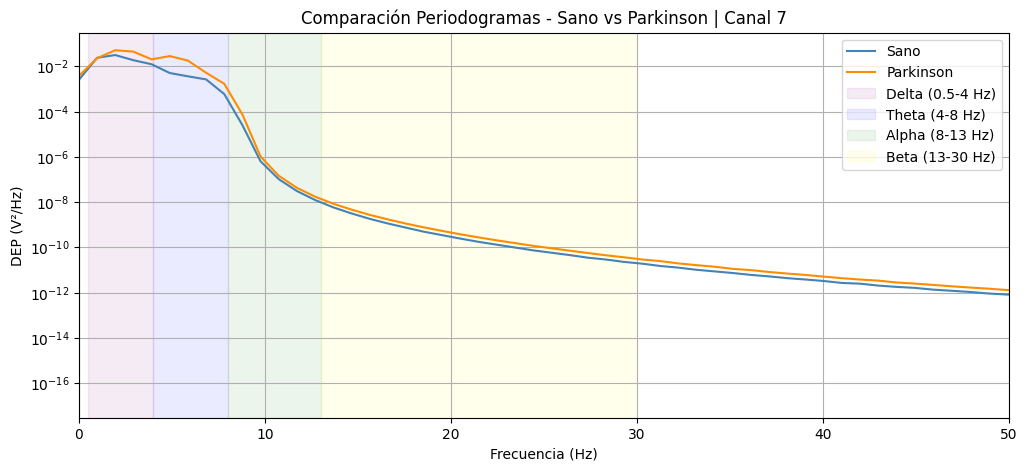

In [ ]:
# Comparación en una sola gráfica con bandas fisiológicas
plt.figure(figsize=(12, 5))
plt.semilogy(f_sano, Pxx_sano,  label='Sano',     color='steelblue')
plt.semilogy(f_park, Pxx_park,  label='Parkinson', color='darkorange')

# Regiones de bandas fisiológicas relevantes en Parkinson
plt.axvspan(0.5,  4,  alpha=0.08, color='purple', label='Delta (0.5-4 Hz)')
plt.axvspan(4,    8,  alpha=0.08, color='blue',   label='Theta (4-8 Hz)')
plt.axvspan(8,   13,  alpha=0.08, color='green',  label='Alpha (8-13 Hz)')
plt.axvspan(13,  30,  alpha=0.08, color='yellow', label='Beta (13-30 Hz)')

plt.title(f'Comparación Periodogramas - Sano vs Parkinson | Canal {canal}')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('DEP (V²/Hz)')
plt.xlim([0, 50])
plt.legend()
plt.grid(True)
plt.show()

In [87]:
# Calculamos la potencia por banda para poder dar informacion cuantitativa
# Se definen los rangos de las bandas fisiológicas del EEG de interés
# cada entrada es: 'nombre': (frecuencia_inferior, frecuencia_superior)
bandas = {
    'Delta (0.5-4 Hz)' : (0.5,  4),
    'Theta (4-8 Hz)'   : (4,    8),
    'Alpha (8-13 Hz)'  : (8,   13),
    'Beta  (13-30 Hz)' : (13,  30)
}

print(f"\n{'Banda':<20} {'Sano':>14} {'Parkinson':>14} {'Diferencia %':>14}")
print("-" * 64)

for nombre, (f_low, f_high) in bandas.items():
    
    # Máscara booleana que selecciona únicamente los índices frecuenciales
    # que caen dentro del rango de cada banda
    idx_s = (f_sano >= f_low) & (f_sano <= f_high)
    idx_p = (f_park >= f_low) & (f_park <= f_high)

    # La potencia de cada banda se obtiene integrando la DEP (V²/Hz) sobre
    # el rango de frecuencias correspondiente usando la regla del trapecio.
    # Esto equivale a calcular el área bajo la curva del periodograma en esa banda,
    # cuyo resultado tiene unidades de V² (energía por unidad de tiempo)
    pot_sano = np.trapezoid(Pxx_sano[idx_s], f_sano[idx_s])
    pot_park = np.trapezoid(Pxx_park[idx_p], f_park[idx_p])

    # La diferencia porcentual se calcula tomando al paciente SANO como referencia,
    # un valor positivo indica que Parkinson tiene MÁS potencia en esa banda,
    # un valor negativo indicaría que tiene MENOS potencia respecto al sano
    diff = ((pot_park - pot_sano) / pot_sano) * 100

    print(f"{nombre:<20} {pot_sano:>14.2e} {pot_park:>14.2e} {diff:>13.1f}%")


Banda                          Sano      Parkinson   Diferencia %
----------------------------------------------------------------
Delta (0.5-4 Hz)           6.76e-02       1.17e-01          72.5%
Theta (4-8 Hz)             9.01e-03       3.78e-02         319.4%
Alpha (8-13 Hz)            1.32e-05       3.80e-05         188.1%
Beta  (13-30 Hz)           1.14e-08       1.70e-08          49.1%


Para la estimación espectral se empleó el método de Welch con ventana Hanning de 
256 muestras ($T_{ventana} = 256/250 = 1.024$ s), seleccionada por su capacidad de 
minimizar fugas espectrales en señales con componentes de muy distinta amplitud como el 
EEG [1]. Esto garantiza una resolución de $\Delta f = 250/256$, es decir, aproximadamente 
$0.98$ Hz, adecuada para separar las bandas delta, theta, alpha y beta. El **solapamiento 
del 50%** (128 muestras) maximiza el número de segmentos disponibles y estabiliza el 
estimador espectral sin incrementar significativamente el costo computacional [2].

A simple vista se observa que la señal del paciente con Parkinson (naranja) se mantiene 
consistentemente por encima de la del paciente sano (azul), siendo la diferencia más 
pronunciada entre 0 y 8 Hz, correspondiente a las bandas delta y theta, lo que sugiere 
una mayor actividad eléctrica cerebral en reposo asociada al enlentecimiento del EEG, 
fenómeno característico de la disfunción tálamo-cortical producida por la degeneración 
dopaminérgica propia de la enfermedad de Parkinson.

Los periodogramas del canal 7 revelan diferencias espectrales notables entre ambos pacientes. 
La más llamativa se observa en la banda theta (4-8 Hz), donde el paciente con Parkinson 
presenta una potencia 319.4% mayor que el sano, asociado a disfunción en los ganglios 
basales [3], [4]. La banda delta (0.5-4 Hz) muestra un aumento del 72.5%, relacionado 
con alteraciones en los circuitos tálamo-corticales [5], [6]. La banda alpha (8-13 Hz)
presenta un incremento del 188.1%, reflejo de la desaceleración del ritmo dominante 
posterior reportada en neurodegeneración [7]. La banda beta (13-30 Hz)nmuestra la menor 
diferencia relativa (49.1%), posiblemente por limitaciones del canal superficial para 
capturar la sincronización beta subcortical [8].

# **Conclusiones**

**1.** Se verificó que el muestreo periódico de una señal analógica produce representaciones 
en tiempo discreto equivalentes independientemente de si el eje horizontal se expresa en 
segundos o en número de muestras. La comparación numérica de las primeras cinco muestras 
de $x(t)$ y $x_1(n)$, con valores idénticos de $[0,\ 1.243,\ 2.409,\ 3.423,\ 4.222]$ V, 
confirmó esta equivalencia, evidenciando que la escala temporal es una elección de 
representación y no altera la información de la señal.

**2.** Se comprobó que la potencia media de una sinusoide es $P = A^2/2$, resultado 
independiente del número de ciclos analizados. Esto tiene implicaciones directas en el 
diseño de sistemas de adquisición de bioseñales, ya que la potencia es una propiedad 
intrínseca de la señal y no del intervalo de observación.

**3.** Se demostró que la FFT permite identificar con precisión las componentes frecuenciales 
de una señal compuesta. Para la señal formada por 40, 80 y 160 Hz, el espectro de magnitud 
mostró tres picos perfectamente diferenciados, validando el uso de la transformada de Fourier 
como herramienta de diagnóstico espectral.

**4.** Se verificó que la IFFT reconstruye fielmente la señal original en el dominio del 
tiempo, confirmando la reversibilidad de la transformada. La manipulación selectiva de 
coeficientes espectrales equivale a la aplicación de un filtro pasa banda ideal, permitiendo 
aislar componentes individuales de la señal sin distorsión visible.

**5.** En el análisis del ECG, el periodograma de Welch reveló un pico de interferencia 
prominente a 60 Hz correspondiente al ruido de la red eléctrica. Tras su eliminación 
mediante anulación selectiva de coeficientes de la FFT y reconstrucción por IFFT, la señal 
filtrada presentó una morfología cardíaca limpia con los complejos QRS y los picos R 
claramente identificables, confirmando la efectividad del procedimiento.

**6.** El análisis comparativo de EEG entre un paciente sano y uno con Parkinson mediante 
el periodograma de Welch reveló diferencias espectrales significativas en todas las bandas 
fisiológicas. El incremento más destacado se presentó en la banda theta (319.4%), seguido 
de alpha (188.1%), delta (72.5%) y beta (49.1%), todos con mayor potencia en el paciente 
con Parkinson. Este patrón de redistribución de energía hacia las bajas frecuencias es 
consistente con la literatura clínica y refleja la disfunción en los circuitos 
tálamo-corticales característica de esta patología, sugiriendo que el análisis espectral 
mediante periodogramas de Welch tiene potencial real como herramienta de apoyo en el 
diagnóstico diferencial de la enfermedad de Parkinson.

# **Referencias**

[1] Sapien Labs, "Factors that impact power spectral density estimation from EEG," 
*Sapien Labs Technical Blog*, May 2023. [Online]. Available: 
https://sapienlabs.org/factors-that-impact-power-spectrum-density-estimation/

[2] Z. Shao et al., "The applied principles of EEG analysis methods in neuroscience and 
clinical neurology," *Frontiers in Neuroscience*, vol. 17, 2023. [Online]. Available: 
https://pmc.ncbi.nlm.nih.gov/articles/PMC10729551/

[3] A. Moran, H. Bergman, Z. Israel, and I. Bar-Gad, "Alterations in neuronal activity in 
basal ganglia-thalamocortical circuits in the parkinsonian state," *Clinical Neuroscience*, 
vol. 10, no. 4, pp. 417–427, 2004. [Online]. Available: 
https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4318426/

[4] P. Saalasti et al., "Increase of EEG spectral theta power indicates higher risk of the 
development of severe cognitive decline in Parkinson's disease after 3 years," 
*Frontiers in Aging Neuroscience*, vol. 8, p. 278, 2016. [Online]. Available: 
https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5126063/

[5] M. Caviness et al., "The Increase of Theta Power and Decrease of Alpha/Theta Ratio as 
a Manifestation of Cognitive Impairment in Parkinson's Disease," *Journal of Clinical 
Medicine*, vol. 12, no. 4, p. 1569, 2023. [Online]. Available: 
https://www.mdpi.com/2077-0383/12/4/1569

[6] P. A. Robinson et al., "Mean-field modeling of the basal ganglia-thalamocortical system. 
II. Dynamics of parkinsonian oscillations," *arXiv preprint*, arXiv:1801.01821, 2018. 
[Online]. Available: https://arxiv.org/pdf/1801.01821

[7] R. Pijnenburg et al., "Spectral features of resting-state EEG in Parkinson's Disease: 
A multicenter study using functional data analysis," *Clinical Neurophysiology*, vol. 151, 
pp. 28–41, 2023. [Online]. Available: 
https://www.sciencedirect.com/science/article/pii/S1388245723005989

[8] J. Yael et al., "Oscillatory Signatures of Parkinson's Disease: Central and Parietal EEG 
Alterations Across Multiple Frequency Bands," *arXiv preprint*, arXiv:2503.12392, 2025. 
[Online]. Available: https://arxiv.org/html/2503.12392
